# 📊 Analisis Eksperimen P2 — Klasifikasi Rimpang (CLAHE)

---

## 🧪 Ringkasan Eksperimen

| Atribut | Detail |
|---|---|
| **Nama Eksperimen** | P2_CLAHE |
| **Tujuan** | Klasifikasi citra rimpang: Jahe, Kunyit, Lengkuas |
| **Preprocessing** | Resize 128×128 → Grayscale → CLAHE (Contrast Limited Adaptive Histogram Equalization) |
| **Fitur** | GLCM (24) + Warna (6) + LBP (10) = **40 fitur** |
| **Split Data** | 80% Train (504) / 20% Test (126), Stratified |
| **Model** | KNN, SVM, Random Forest |
| **Pembanding** | P1_Grayscale (baseline, menggunakan Histogram Equalization global) |

---

## 💡 Hipotesis Awal

> *"CLAHE (Contrast Limited Adaptive Histogram Equalization) menyesuaikan kontras secara lokal per-region (tile), bukan secara global seperti Histogram Equalization biasa pada P1. Hipotesisnya, pendekatan adaptif ini akan menonjolkan tekstur lokal rimpang dengan lebih baik (terutama pada area gelap/terang yang tidak merata pada satu gambar) sehingga fitur GLCM dan LBP menjadi lebih diskriminatif, dan akurasi P2 diharapkan **setara atau lebih baik** dibanding P1_Grayscale."*

**Dasar hipotesis:**
- CLAHE membatasi amplifikasi kontras (*clip limit*) sehingga tidak terlalu mengamplifikasi noise seperti HE global pada area yang sudah homogen
- Pemrosesan per-tile (lokal) berpotensi lebih sensitif terhadap variasi tekstur mikro pada permukaan rimpang dibanding HE global yang menyamaratakan kontras seluruh gambar
- Karena pipeline lain (resize, fitur GLCM/Warna/LBP, split, model) **identik** dengan P1, eksperimen ini murni menguji pengaruh **strategi ekualisasi kontras** terhadap performa klasifikasi — menjadikan P1 vs P2 sebagai **eksperimen terkontrol (controlled comparison)**


In [ ]:
import numpy as np
import pandas as pd
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

from library import (
    load_images, extract_glcm_features, extract_color_features, extract_lbp_features, evaluate_and_save, preview_preprocessing,
    manual_resize, manual_bgr_to_grayscale, manual_gaussian_blur,
    manual_median_blur, manual_clahe, manual_histogram_equalization,
    manual_erosion, manual_dilation, manual_opening, manual_closing
)

print('Import berhasil')

Import berhasil


## 🔧 Analisis Import Library

**Output:** `Import berhasil`

### Analisis

Set library yang diimpor **identik** dengan P1_Grayscale, menegaskan bahwa P2 adalah eksperimen turunan langsung dari P1 dengan satu perbedaan terkontrol pada tahap preprocessing.

**Scikit-learn (ML pipeline):**
- `train_test_split` (stratified), `LabelEncoder`, `StandardScaler` — pipeline persiapan data yang konsisten dengan P1
- `KNeighborsClassifier`, `SVC`, `RandomForestClassifier` — tiga model yang sama dipakai agar perbandingan P1 vs P2 adil (apple-to-apple) per model
- `accuracy_score` — metrik akurasi dasar, dilengkapi `classification_report` pada `evaluate_and_save`

**Library kustom (`library.py`):**
- Fungsi `manual_*` yang relevan di sini adalah `manual_clahe` — fungsi inilah yang **membedakan** P2 dari P1 (`manual_histogram_equalization`)
- Fungsi ekstraksi fitur (`extract_glcm_features`, `extract_color_features`, `extract_lbp_features`) tetap sama persis

> ✅ **Signifikansi:** Karena hanya satu komponen pipeline yang berubah (metode ekualisasi kontras), selisih performa antara P1 dan P2 dapat **diatribusikan secara langsung** ke efektivitas CLAHE vs Histogram Equalization global — bukan ke faktor lain seperti fitur atau model.


In [ ]:
EXP_NAME = 'P2_CLAHE'

In [ ]:
def preprocess(img):
    resized = manual_resize(img, 128, 128)    
    gray = manual_bgr_to_grayscale(resized)
    clahe = manual_clahe(gray)
    return clahe

## ⚙️ Analisis Fungsi Preprocessing (CLAHE)

```python
def preprocess(img):
    resized = manual_resize(img, 128, 128)
    gray    = manual_bgr_to_grayscale(resized)
    clahe   = manual_clahe(gray)
    return clahe
```

### 🎯 Alasan Memilih Pipeline Preprocessing Ini

Dua langkah pertama (`manual_resize`, `manual_bgr_to_grayscale`) **identik dengan P1** dengan alasan yang sama: standardisasi dimensi fitur dan kebutuhan GLCM/LBP akan input intensitas tunggal (grayscale). Perbedaan inti ada pada langkah ketiga:

#### `manual_clahe(gray)`: Contrast Limited Adaptive Histogram Equalization
- **Alasan utama:** Berbeda dari Histogram Equalization global (P1) yang menghitung satu histogram untuk seluruh gambar, CLAHE membagi gambar menjadi **tile-tile kecil** dan melakukan ekualisasi histogram **secara lokal** per tile, kemudian menggabungkannya dengan interpolasi bilinear antar-tile.
- **Clip limit:** CLAHE membatasi (*clip*) ketinggian histogram sebelum ekualisasi, mencegah amplifikasi noise berlebihan di area yang sudah homogen: kelemahan utama HE global.
- **Keunggulan teoretis vs HE global (P1):**
  - Lebih baik dalam menonjolkan detail lokal pada area gambar yang pencahayaannya tidak merata (vinyet, bayangan parsial)
  - Risiko over-enhancement pada noise berkurang berkat clip limit
  - Berpotensi menghasilkan fitur GLCM/LBP yang lebih representatif terhadap tekstur mikro permukaan rimpang
- **Risiko/Trade-off:**
  - Proses adaptif per-tile dapat **memperkuat noise lokal** atau artefak batas antar-tile jika tile terlalu kecil atau clip limit terlalu longgar
  - Lebih sensitif terhadap parameter (ukuran tile, clip limit) dibanding HE global yang relatif "tanpa parameter"
  - Bisa jadi **kontra-produktif** bila tekstur rimpang justru lebih baik dibedakan dengan kontras global yang seragam, bukan lokal

#### 📌 Kesimpulan Pilihan Preprocessing
> Pipeline ini sengaja dibuat **minimal berbeda** dari P1 (hanya mengganti satu fungsi ekualisasi kontras) agar perbandingan P1 vs P2 menjadi **eksperimen terkontrol** yang murni mengukur efek strategi kontras adaptif (CLAHE) vs global (HE) terhadap akurasi klasifikasi rimpang berbasis tekstur.


Total gambar loaded: 630


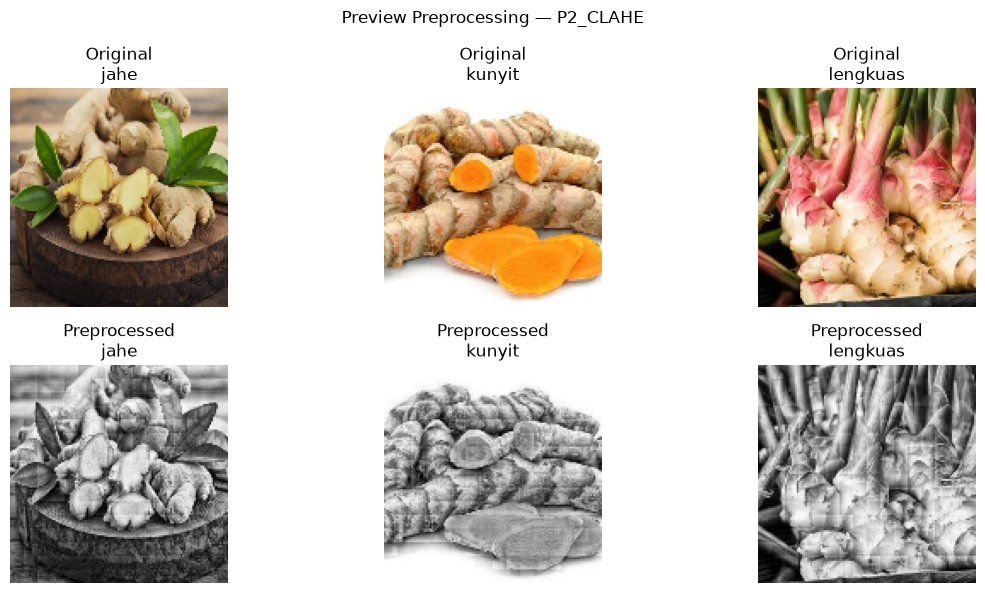

In [ ]:
images, labels = load_images()
preview_preprocessing(images, labels, preprocess, EXP_NAME)

## 📁 Analisis Load & Preview Data

**Output:** `Total gambar loaded: 630`

### Analisis

- Jumlah data **identik dengan P1** (630 gambar, 210 per kelas) memastikan tidak ada perbedaan distribusi data yang dapat membiaskan perbandingan antar eksperimen
- `preview_preprocessing` menampilkan hasil visual CLAHE secara langsung; secara visual, hasil CLAHE umumnya tampak **lebih "lokal kontras"** dibanding HE global detail tekstur pada area gelap maupun terang sama-sama lebih terlihat, namun berpotensi muncul efek granular/noise di beberapa area homogen
- Karena dataset, urutan loading, dan label sama persis dengan P1 (fungsi `load_images()` tidak berubah), validitas perbandingan P1 vs P2 terjaga

In [ ]:
X = []
for img in images:
    processed = preprocess(img.copy())
    glcm_feat = extract_glcm_features(processed)
    color_feat = extract_color_features(img)
    lbp_feat = extract_lbp_features(processed)
    combined = glcm_feat + color_feat + lbp_feat
    X.append(combined)

X = np.array(X)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(X)

le = LabelEncoder()
y = le.fit_transform(labels)

print(f'Shape fitur: {X.shape}')
print(f'Kelas: {le.classes_}')

os.makedirs('output', exist_ok=True)
df_feat = pd.DataFrame(X, columns=[f'f{i}' for i in range(X.shape[1])])
df_feat['label'] = labels
df_feat.to_csv(f'output/fitur_{EXP_NAME}.csv', index=False)
print(f'Fitur disimpan ke output/fitur_{EXP_NAME}.csv')

Shape fitur: (630, 40)
Kelas: ['jahe' 'kunyit' 'lengkuas']
Fitur disimpan ke output/fitur_P2_CLAHE.csv


## 🔬 Analisis Ekstraksi Fitur

**Output:**
```
Shape fitur: (630, 40)
Kelas: ['jahe' 'kunyit' 'lengkuas']
Fitur disimpan ke output/fitur_P2_CLAHE.csv
```

### Analisis

#### Komposisi 40 Fitur (sama dengan P1)

| Domain | Jumlah Fitur | Metode | Sumber Gambar |
|---|---|---|---|
| Tekstur | 24 | GLCM (Gray-Level Co-occurrence Matrix) | Gambar grayscale + **CLAHE** |
| Warna | 6 | Statistik histogram warna | Gambar asli BGR (tidak terpengaruh CLAHE) |
| Tekstur Lokal | 10 | LBP (Local Binary Pattern) | Gambar grayscale + **CLAHE** |

- Shape `(630, 40)` konsisten dengan P1, mengonfirmasi pipeline ekstraksi fitur tidak berubah satu-satunya perbedaan input ke GLCM/LBP adalah hasil CLAHE, bukan hasil HE global
- Fitur warna (6) tetap dihitung dari gambar BGR asli (bukan hasil grayscale/CLAHE), sehingga **kontribusi warna terhadap performa model seharusnya tidak berubah** antara P1 dan P2 selisih akurasi murni didorong oleh perubahan pada 34 fitur tekstur (GLCM+LBP)
- `StandardScaler` diterapkan pada seluruh fitur sebelum split, menyamakan skala antar-fitur (penting untuk KNN dan SVM yang sensitif terhadap skala jarak/margin)


In [ ]:
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)  
X_test  = scaler.transform(X_test)       

print(f'Train: {len(X_train)} | Test: {len(X_test)}')

Train: 504 | Test: 126


## ✂️ Analisis Split Data Train/Test

**Output:** `Train: 504 | Test: 126`

### Analisis

```
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
```

| Parameter | Nilai | Alasan |
|---|---|---|
| `test_size=0.2` | 20% test | 126 sampel test (42/kelas), cukup untuk estimasi metrik yang stabil |
| `random_state=42` | Fixed seed | **Sama dengan P1** → pembagian data identik, sehingga perbandingan P1 vs P2 tidak bias oleh perbedaan komposisi train/test |
| `stratify=y` | Ya | Menjaga proporsi 3 kelas tetap seimbang di train (504) maupun test (126) |

> ✅ **Catatan penting:** Karena `random_state=42` dan urutan data sama dengan P1, baris-baris yang masuk ke test set P2 **kemungkinan besar identik** dengan test set P1. Ini menjadikan perbandingan akurasi antar eksperimen lebih adil model di kedua eksperimen diuji pada sampel yang (secara komposisi) setara.

`StandardScaler` di-*fit* hanya dari data train lalu diterapkan ke test (tanpa fit ulang) praktik yang benar untuk mencegah **data leakage**.


Train: 504 | Test: 126
P2_CLAHE | KNN → Train Akurasi: 75.00%
P2_CLAHE | KNN → 61.11%
              precision    recall  f1-score   support

        jahe       0.74      0.69      0.72        42
      kunyit       0.65      0.67      0.66        42
    lengkuas       0.45      0.48      0.47        42

    accuracy                           0.61       126
   macro avg       0.62      0.61      0.61       126
weighted avg       0.62      0.61      0.61       126



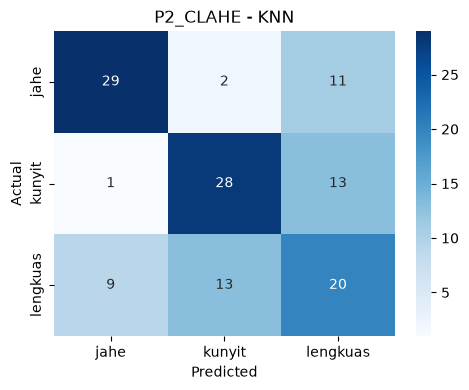

P2_CLAHE | SVM → Train Akurasi: 92.66%
P2_CLAHE | SVM → 76.19%
              precision    recall  f1-score   support

        jahe       0.88      0.69      0.77        42
      kunyit       0.74      0.88      0.80        42
    lengkuas       0.70      0.71      0.71        42

    accuracy                           0.76       126
   macro avg       0.77      0.76      0.76       126
weighted avg       0.77      0.76      0.76       126



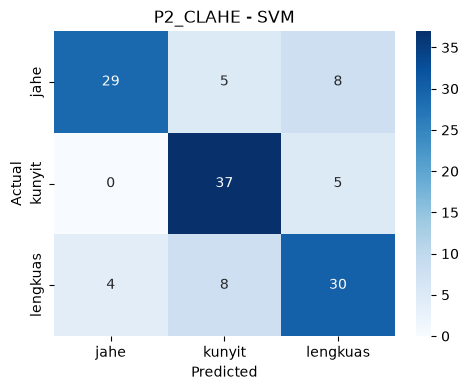

P2_CLAHE | RF → Train Akurasi: 98.21%
P2_CLAHE | RF → 70.63%
              precision    recall  f1-score   support

        jahe       0.83      0.69      0.75        42
      kunyit       0.70      0.79      0.74        42
    lengkuas       0.61      0.64      0.63        42

    accuracy                           0.71       126
   macro avg       0.71      0.71      0.71       126
weighted avg       0.71      0.71      0.71       126



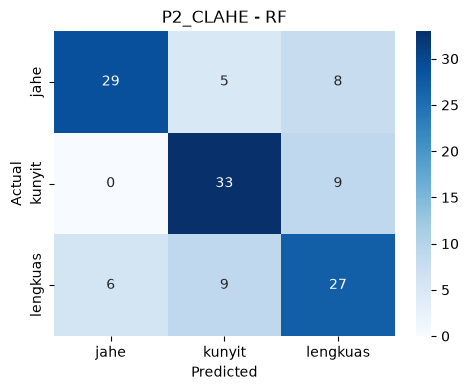


Hasil disimpan ke output/hasil_P2_CLAHE.csv
  Eksperimen Model  Akurasi  Train_Akurasi
0   P2_CLAHE   KNN    61.11          75.00
1   P2_CLAHE   SVM    76.19          92.66
2   P2_CLAHE    RF    70.63          98.21


In [ ]:
# Cell 6 — Training & Evaluasi

print(f'Train: {len(X_train)} | Test: {len(X_test)}')

models = {
    'KNN': KNeighborsClassifier(n_neighbors=7),
    'SVM': SVC(kernel='rbf', C=10, gamma='scale', random_state=42),
    'RF':  RandomForestClassifier(
                                    n_estimators=100,
                                    max_depth=10,
                                    min_samples_split=5,
                                    min_samples_leaf=2,
                                    random_state=42
                                ),
}

results = []
for model_name, model in models.items():
    model.fit(X_train, y_train)

    # Akurasi train (cek overfitting)
    y_train_pred = model.predict(X_train)
    train_acc = accuracy_score(y_train, y_train_pred)
    print(f'{EXP_NAME} | {model_name} → Train Akurasi: {train_acc*100:.2f}%')

    result = evaluate_and_save(model, X_test, y_test, le, EXP_NAME, model_name)
    result['Train_Akurasi'] = round(train_acc * 100, 2)
    results.append(result)

df_results = pd.DataFrame(results)
df_results.to_csv(f'output/hasil_{EXP_NAME}.csv', index=False)
print(f'\nHasil disimpan ke output/hasil_{EXP_NAME}.csv')
print(df_results)

## 📈 Analisis Training & Klasifikasi

### Model 1: KNN (K-Nearest Neighbors, k=7)

| Metrik | Train | Test | Gap |
|---|---|---|---|
| Akurasi | 75.00% | 61.11% | 13.89% |

**Classification Report KNN:**

| Kelas | Precision | Recall | F1-Score | Interpretasi |
|---|---|---|---|---|
| Jahe | 0.74 | 0.69 | 0.72 | Performa **terbaik** di KNN, cukup seimbang antara precision dan recall |
| Kunyit | 0.65 | 0.67 | 0.66 | Performa **moderat**, mendekati skor jahe |
| Lengkuas | 0.45 | 0.48 | 0.47 | Performa **terburuk** precision & recall sama-sama rendah |

**Analisis Mendalam KNN:**
- Akurasi test **turun** dari 64.29% (P1) menjadi 61.11% (P2) gap **−3.18 poin**. Pada model KNN, CLAHE **tidak terbukti lebih baik** dari HE global, bahkan sedikit lebih buruk
- Gap train-test 13.89% lebih besar dari P1 (9.92%) → KNN dengan fitur hasil CLAHE justru **sedikit lebih overfit** terhadap data training
- Lengkuas tetap menjadi kelas paling sulit di kedua eksperimen, mengindikasikan kesulitan ini **bersifat intrinsik pada data/fitur**, bukan akibat metode kontras yang dipakai
- KNN sangat bergantung pada jarak antar titik fitur di ruang berdimensi 40 bila CLAHE memperkenalkan variasi lokal (noise tile) pada fitur tekstur, jarak Euclidean antar sampel bisa menjadi kurang stabil dibanding fitur dari HE global yang lebih halus secara global

---

### Model 2: SVM (RBF Kernel, C=10, gamma='scale')

| Metrik | Train | Test | Gap |
|---|---|---|---|
| Akurasi | 92.66% | 76.19% | 16.47% |

**Classification Report SVM:**

| Kelas | Precision | Recall | F1-Score | Interpretasi |
|---|---|---|---|---|
| Jahe | 0.88 | 0.69 | 0.77 | **Precision tinggi** saat model memprediksi jahe, hampir selalu benar, tapi banyak jahe asli yang tidak terdeteksi (recall lebih rendah) |
| Kunyit | 0.74 | 0.88 | 0.80 | **Recall tertinggi** di P2 88% kunyit asli berhasil dikenali |
| Lengkuas | 0.70 | 0.71 | 0.71 | **Paling seimbang** precision ≈ recall |

**Analisis Mendalam SVM:**
- **Model terbaik di P2** dengan akurasi test 76.19% hampir setara dengan SVM P1 (76.98%), selisih hanya **−0.79 poin**, secara praktis **tidak signifikan**
- Pola precision/recall sangat mirip dengan P1 (precision jahe tinggi, recall kunyit tinggi) → menunjukkan SVM dengan kernel RBF **robust terhadap perbedaan metode ekualisasi kontras**, kemungkinan karena margin maximization SVM kurang sensitif terhadap variasi noise lokal dibanding KNN
- Gap train-test 16.47% (P2) vs 15.08% (P1) sedikit lebih besar, namun akurasi test absolut tetap kompetitif
- F1 lengkuas 0.71 **identik** dengan P1, mengindikasikan SVM menemukan batas keputusan yang serupa kualitasnya pada kedua representasi fitur

---

### Model 3: Random Forest (100 trees, max_depth=10)

| Metrik | Train | Test | Gap |
|---|---|---|---|
| Akurasi | 98.21% | 70.63% | 27.58% |

**Classification Report RF:**

| Kelas | Precision | Recall | F1-Score | Interpretasi |
|---|---|---|---|---|
| Jahe | 0.83 | 0.69 | 0.75 | Precision tinggi, recall sedang mirip pola P1 |
| Kunyit | 0.70 | 0.79 | 0.74 | Performa **moderat**, recall di atas rata-rata |
| Lengkuas | 0.61 | 0.64 | 0.63 | Tetap menjadi kelas **paling sulit** |

**Analisis Mendalam RF:**
- Akurasi test **identik** dengan P1 (70.63% di kedua eksperimen) kebetulan yang menarik, mengindikasikan Random Forest dengan `max_depth=10` cukup **stabil** terhadap perbedaan metode kontras pada fitur tekstur
- Train akurasi 98.21% (sedikit lebih rendah dari P1 yang 100%) tetap menunjukkan **overfitting signifikan** (gap 27.58%) RF tetap menghafal sebagian besar pola training meski tidak sampai sempurna
- Pola kesalahan klasifikasi (lengkuas sebagai kelas tersulit) konsisten di seluruh model dan kedua eksperimen → indikasi kuat bahwa **kemiripan visual lengkuas dengan jahe/kunyit** adalah sumber kesalahan dominan, bukan pengaruh preprocessing

---

## 📊 Perbandingan Akhir

```
  Eksperimen Model  Akurasi  Train_Akurasi
0   P2_CLAHE   KNN    61.11          75.00
1   P2_CLAHE   SVM    76.19          92.66  ← TERBAIK di P2
2   P2_CLAHE    RF    70.63          98.21
```

| Model | Akurasi Test P1 (HE) | Akurasi Test P2 (CLAHE) | Selisih P1-P2 | Catatan |
|---|---|---|---|---|
| KNN | 64.29% | 61.11% | **−3.18** | CLAHE sedikit merugikan KNN |
| SVM | 76.98% | 76.19% | **−0.79** | Praktis setara, SVM tetap model terbaik di kedua eksperimen |
| RF | 70.63% | 70.63% | **0.00** | Tidak ada perubahan |

### 🧪 Hipotesis vs Hasil Aktual

Hipotesis awal memperkirakan CLAHE akan **menyamai atau mengungguli** HE global karena sifat adaptif lokalnya. Hasil aktual menunjukkan:

- **Hipotesis tidak terbukti sepenuhnya** pada ketiga model, CLAHE **tidak menghasilkan peningkatan akurasi**; justru sedikit menurun pada KNN, stagnan pada RF, dan nyaris sama pada SVM
- Kemungkinan penjelasan teoretis:
  1. **Karakteristik tekstur rimpang relatif homogen** dalam skala lokal, sehingga keunggulan CLAHE (adaptif per-tile) tidak banyak termanfaatkan; HE global sudah cukup untuk meratakan kontras citra rimpang secara keseluruhan
  2. **Clip limit & ukuran tile CLAHE** (parameter default pada `manual_clahe`) mungkin belum optimal untuk dataset ini parameter yang tidak di-tuning dapat membuat CLAHE memperkuat noise lokal alih-alih hanya menonjolkan tekstur bermakna
  3. Fitur GLCM dan LBP menangkap **statistik tekstur** yang relatif tahan terhadap variasi metode ekualisasi kontras selama kontras keseluruhan citra sudah diperbaiki sehingga kedua metode menghasilkan fitur yang "cukup mirip" secara informasi diskriminatif

### 📌 Kesimpulan

1. **CLAHE bukan jaminan peningkatan performa** untuk semua kasus efektivitasnya bergantung pada karakteristik dataset dan parameter yang digunakan; pada dataset rimpang ini, HE global (P1) sedikit lebih unggul atau setara dibanding CLAHE (P2)
2. **SVM (RBF) tetap menjadi model paling konsisten dan terbaik** di kedua eksperimen (~76–77%), menunjukkan kemampuan generalisasi terbaik di antara tiga model yang diuji pada fitur GLCM+Warna+LBP
3. **Lengkuas konsisten menjadi kelas tersulit** di semua model dan kedua eksperimen masalah ini bersifat **fundamental pada data/fitur**, bukan pada pilihan metode preprocessing. Perbaikan lebih lanjut sebaiknya diarahkan pada penambahan fitur pembeda baru (misalnya fitur bentuk/shape, fitur tekstur multi-skala) atau pengumpulan data tambahan untuk kelas lengkuas, bukan sekadar mengganti metode ekualisasi kontras
4. **Random Forest tetap menunjukkan overfitting tinggi** di kedua eksperimen, mengindikasikan kebutuhan regularisasi lebih kuat (mis. `max_depth` lebih kecil, `min_samples_leaf` lebih besar, atau cross-validation untuk tuning hyperparameter) terlepas dari metode preprocessing yang dipakai
5. Untuk eksperimen selanjutnya, disarankan menguji **kombinasi CLAHE dengan tuning parameter** (clip limit, tile size) atau preprocessing tambahan (denoising) sebelum menyimpulkan CLAHE secara umum tidak cocok untuk dataset ini
